# Heat Conduction with XLB

This notebook is an introduction to **scalar transport** in [XLB](https://github.com/Autodesk/XLB).
We start from the simplest possible case: heat conduction with no fluid motion at all.

**The problem, in plain terms:** imagine a solid slab. We hold its top and bottom faces at a
fixed cold temperature, insulate its sides so no heat escapes there, and then heat the whole
slab from within — think of electrical resistance heating, or a nuclear fuel element producing
heat by fission. Heat piles up in the middle and flows outward to the cold faces. After a
while nothing changes any more, and we are left with a steady temperature profile that is
hottest at the centre.

The equation we are solving is the **heat equation with a source**,

$$\rho c_p \frac{\partial T}{\partial t} = k \Delta T + q''',$$

where $\rho$ is density, $c_p$ specific heat, $k$ thermal conductivity, and $q'''$ the
volumetric heat generation rate. Dividing through by $\rho c_p$ gives the form the solver
actually works with,

$$\frac{\partial T}{\partial t} = \alpha \Delta T + S, \qquad
\alpha = \frac{k}{\rho c_p}, \qquad S = \frac{q'''}{\rho c_p},$$

with $\alpha$ the **thermal diffusivity**.

**What makes this different from the fluid tutorials.** The lid-driven cavity notebook solves
the Navier-Stokes equations, where the unknowns are density and velocity. Here the unknown is
a single number per point — the temperature. In lattice Boltzmann language that means we need
a **second, separate set of populations**, conventionally called $g_i$, that lives alongside
(or entirely without) the flow populations $f_i$. Everything in this notebook is about those
$g_i$.

## Prerequisites

Install XLB. As in the other tutorials we use the **JAX backend**, which is the most
convenient one to work with interactively: the population arrays are ordinary JAX arrays that
you can print, slice, and plot directly. The same code runs on the Warp backend with only a
change to `compute_backend`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import xlb
import xlb.velocity_set
from xlb.compute_backend import ComputeBackend
from xlb.grid import grid_factory
from xlb.helper import omega_from_diffusivity, diffusivity_from_omega
from xlb.operator.boundary_condition import ScalarDirichletBC, ScalarNeumannBC
from xlb.operator.macroscopic import ZeroMoment
from xlb.operator.stepper import ThermalStepper
from xlb.precision_policy import PrecisionPolicy

FIG_DIR = Path("figures/heat_equation_2d")
FIG_DIR.mkdir(parents=True, exist_ok=True)

---
## Step 1 — How a lattice Boltzmann scheme carries a scalar

It is worth understanding the model before writing any code, because it explains almost every
API choice that follows.

The flow solver stores populations $f_i$ whose **zeroth moment** is the density and whose
**first moment** is the momentum. For a scalar we need far less: the temperature is just the
zeroth moment,

$$T = \sum_i g_i .$$

The populations relax towards an equilibrium in exactly the same BGK fashion as the flow,

$$g_i(\mathbf{x} + \mathbf{c}_i, t+1) = g_i(\mathbf{x}, t)
- \omega \left[ g_i(\mathbf{x},t) - g_i^{\rm eq}(\mathbf{x},t) \right] + w_i S,$$

where the last term is the **volumetric source**. Here $S$ is the macroscopic source in the
continuum equation — for the heat equation, the heating rate per unit mass divided by $\rho c_p$,

$$S = \frac{q'''}{\rho c_p},$$

with $q'''$ the volumetric heat generation rate ($W/m^3$). In lattice units the field passed to
`ScalarSource` is the temperature increment per time step, $S_{\rm lattice} = q''' \Delta t /
(\rho c_p)$. The factor $w_i$ distributes that source across the populations while keeping the
zeroth moment exact: $\sum_i w_i S = S$ because the weights sum to one. In XLB this is the
`ScalarSource` operator (`g_i ← g_i + w_i S`).

The equilibrium is **linear** in the velocity rather than quadratic:

$$g_i^{\rm eq} = w_i \, T \left( 1 + 3\, \mathbf{c}_i \cdot \mathbf{u} \right).$$

Compare this with the flow equilibrium, which carries an extra
$\tfrac{9}{2}(\mathbf{c}_i\cdot\mathbf{u})^2 - \tfrac{3}{2}u^2$. Those quadratic terms exist to
recover the nonlinear advection term of Navier-Stokes. A passive scalar has no such term, so
they are not merely unnecessary — dropping them makes the scheme *exactly* right for
advection-diffusion. In XLB this is the `LinearEquilibrium` operator, as opposed to the
`QuadraticEquilibrium` used by the flow.

In this first notebook we set $\mathbf{u} = 0$, so the equilibrium is simply $g_i^{\rm eq} = w_i T$.

### Two consequences worth remembering

**A smaller stencil is enough.** The flow needs D2Q9 in 2D. A scalar needs only **D2Q5** — the
rest velocity plus the four axis directions. The diagonal links contribute nothing to
isotropic diffusion at this order, so D2Q5 gives the same accuracy for roughly half the memory
and work. XLB ships a `D2Q5` velocity set for precisely this purpose.

**Relaxation rate sets the diffusivity.** Just as $\omega$ encodes viscosity for the flow, it
encodes diffusivity for the scalar — but with a different formula, because the scalar has no
quadratic terms:

$$\alpha = \frac{1}{3}\left(\frac{1}{\omega} - \frac{1}{2}\right)
\qquad \Longleftrightarrow \qquad
\omega = \frac{1}{3\alpha + 1/2}.$$

You rarely want to work that out by hand, so XLB provides `omega_from_diffusivity` and its
inverse `diffusivity_from_omega`.

### References — LBM for thermal and passive-scalar transport

The formulation above — a separate population set $g_i$, a linear equilibrium, BGK collision,
and source terms added after collision — is standard in the LBM heat-transfer literature. Useful
entry points:

1. **Krüger, Kusumaatmaja, Kuzmin, Shardt, Silva & Viggen**, *The Lattice Boltzmann Method:
   Principles and Practice* (Springer, 2017). Ch. 7 covers passive scalars and coupled
   flow–thermal problems; the Boussinesq approximation is discussed in the multiphysics context.
2. **Mohamad**, *Lattice Boltzmann Method: Fundamentals and Engineering Applications with
   Computer Codes* (Springer, 2011). Ch. 6–7 treat heat conduction, convection, and boundary
   conditions for temperature.
3. **Guo, Zheng & Shi**, "Discrete lattice effects on the forcing term in the lattice Boltzmann
   model for convection-diffusion equations", *Computers & Mathematics with Applications* **43**,
   201–209 (2002). Source-term consistency and the relation between lattice forcing and the
   continuum $q'''$ term.
4. **He & Luo**, "A priori derivation of the lattice Boltzmann equation", *Phys. Rev. E* **55**,
   R6333 (1997). Chapman–Enskog analysis underlying the $\omega \leftrightarrow \alpha$ mapping
   and the linear equilibrium for scalars.
5. **Ginzburg & Adler**, "Boundary conditions for lattice Boltzmann equations", *Phys. Rev. E*
   **53**, 6296 (1996). Halfway-wall constructions; the anti-bounce-back Dirichlet condition
   used for fixed wall temperature follows the same logic.
6. **Wang, Guo & Mi**, "A review on the lattice Boltzmann method for computational fluid dynamics
   and heat transfer", *International Journal of Heat and Mass Transfer* **106**, 474–491
   (2017). Broad survey of thermal LBM models, boundary conditions, and coupling strategies.

In [2]:
for alpha in [0.01, 1.0 / 6.0, 0.5]:
    omega = omega_from_diffusivity(alpha)
    print(f"alpha = {alpha:.4f}  ->  omega = {omega:.4f}  ->  alpha again = {diffusivity_from_omega(omega):.4f}")

alpha = 0.0100  ->  omega = 1.8868  ->  alpha again = 0.0100
alpha = 0.1667  ->  omega = 1.0000  ->  alpha again = 0.1667
alpha = 0.5000  ->  omega = 0.5000  ->  alpha again = 0.5000


Note that $\alpha = 1/6$ gives exactly $\omega = 1$, the best-conditioned choice. Staying
roughly within $\alpha \in [0.01, 0.5]$ (that is, $\omega \in [0.5, 1.9]$) keeps the scheme
both accurate and stable. Very small $\alpha$ pushes $\omega \to 2$, where the scheme becomes
noisy; very large $\alpha$ pushes $\omega \to 0$, where it becomes over-diffusive and slow.

---
## Step 2 — Simulation parameters

| Parameter | Role |
|-----------|------|
| `grid_shape` | Number of lattice nodes in x and y |
| `velocity_set` | **D2Q5** — the five-velocity scalar stencil |
| `diffusivity` | Thermal diffusivity $\alpha = k/(\rho c_p)$ in lattice units |
| `source` | Volumetric heating $S = q'''/(\rho c_p)$, per time step |
| `wall_temperature` | Temperature held on the cooled faces |

### A word on units

Everything above is in **lattice units**: lengths in cells, times in steps. The source is
therefore "temperature added per cell per step", i.e. $q''' \Delta t / (\rho c_p)$. Keeping it
small matters — with `source = 1e-6` over 60,000 steps the temperature rises to about
$3\times 10^{-3}$, comfortably small. The heat equation is *linear* in $T$, so the choice of
scale is arbitrary and you can always rescale the answer afterwards. That linearity is a
genuine convenience: unlike the flow solver, there is no Mach number to worry about.

In [3]:
grid_shape = (64, 64)
compute_backend = ComputeBackend.JAX
precision_policy = PrecisionPolicy.FP64FP64

velocity_set = xlb.velocity_set.D2Q5(
    precision_policy=precision_policy,
    compute_backend=compute_backend,
)

diffusivity = 0.2 # 1.0 / 6.0
omega = omega_from_diffusivity(diffusivity)

source_value = 1e-6
wall_temperature = 0.0

print(f"Grid:          {grid_shape[0]} x {grid_shape[1]}")
print(f"Velocity set:  D2Q5 ({velocity_set.q} populations per node)")
print(f"Weights:       w_0 = {velocity_set.w[0]:.4f}, w_i = {velocity_set.w[1]:.4f}")
print(f"Diffusivity:   {diffusivity:.4f}")
print(f"Omega:         {omega:.4f}")

Grid:          64 x 64
Velocity set:  D2Q5 (5 populations per node)
Weights:       w_0 = 0.3333, w_i = 0.1667
Diffusivity:   0.2000
Omega:         0.9091


---
## Step 3 — Initialize XLB and create the grid

As always, `xlb.init` is called once to register the defaults, and `grid_factory` builds the
container that holds our fields.

In [4]:
xlb.init(
    velocity_set=velocity_set,
    default_backend=compute_backend,
    default_precision_policy=precision_policy,
)

grid = grid_factory(grid_shape, compute_backend=compute_backend)

No GPU support is available; CPU fallback will be used.


---
## Step 4 — Thermal boundary conditions

Thermal problems come with two physically distinct kinds of wall condition, and XLB provides
one operator for each.

### `ScalarDirichletBC` — a prescribed temperature

This is the "held at a fixed temperature" wall: a face in contact with a large reservoir, or
an actively cooled surface. It is implemented by **anti-bounce-back**: the population
streaming back from the wall is

$$g_l = -g^{\rm pre}_{\bar{l}} + 2 w_l T_{\rm wall},$$

where $\bar{l}$ is the direction opposite to $l$. The minus sign is the whole point, and it is
what distinguishes this from the fluid `HalfwayBounceBackBC`. A no-slip wall *reflects*
momentum, so it reverses the population and keeps the sign. A fixed-temperature wall must
instead let the anti-symmetric part of the populations pass through while pinning their
symmetric part to $2w_l T_{\rm wall}$ — hence anti-bounce-back. The wall ends up located
exactly halfway between the last fluid node and the first node outside, which is why the
analytical comparisons below use cell-centre coordinates offset by half a cell.

### `ScalarNeumannBC` — a prescribed heat flux

This is the "so much heat crosses this face" wall, and its most useful special case is
`flux=0.0`: a **perfectly insulated (adiabatic)** wall. It is implemented as ordinary
bounce-back with an added flux term,

$$g_l = g^{\rm pre}_{\bar{l}} + 2 c_s^{-2} w_l \, \Phi .$$

With $\Phi = 0$ this is exactly bounce-back, and it makes the wall reflect heat perfectly, so
nothing leaks out.

### Setting up our slab

Cooled top and bottom, insulated left and right.

In [5]:
box = grid.bounding_box_indices()
box_no_edge = grid.bounding_box_indices(remove_edges=True)

cooled = [box["bottom"][i] + box["top"][i] for i in range(velocity_set.d)]
insulated = [box_no_edge["left"][i] + box_no_edge["right"][i] for i in range(velocity_set.d)]

bc_cooled = ScalarDirichletBC(value=wall_temperature, indices=cooled)
bc_insulated = ScalarNeumannBC(flux=0.00, indices=insulated)

boundary_conditions = [bc_cooled, bc_insulated]

print(f"Cooled nodes (Dirichlet):    {len(cooled[0])}")
print(f"Insulated nodes (Neumann):   {len(insulated[0])}")

registered bc ScalarDirichletBC_300202334 with id 1
registered bc ScalarNeumannBC_300202202 with id 2
Cooled nodes (Dirichlet):    128
Insulated nodes (Neumann):   124


---
## Step 5 — The `ThermalStepper`

`ThermalStepper` is to the scalar conduction what `IncompressibleNavierStokesStepper` is to the flow: it
assembles streaming, collision, equilibrium, the moment, the source term, and the boundary
conditions into one complete time step.

It is deliberately **independent of the flow solver**. It owns its own populations and its own
boundary masks, so it can run entirely on its own — which is exactly what we are doing here.

In [6]:
stepper = ThermalStepper(
    grid=grid,
    boundary_conditions=boundary_conditions,
)

print("Operators assembled by the stepper:")
print(f"  equilibrium:  {stepper.equilibrium.__class__.__name__}")
print(f"  collision:    {stepper.collision.__class__.__name__}")
print(f"  moment:       {stepper.zero_moment.__class__.__name__}")
print(f"  source:       {stepper.source.__class__.__name__}")

Operators assembled by the stepper:
  equilibrium:  LinearEquilibrium
  collision:    BGK
  moment:       ZeroMoment
  source:       ScalarSource


---
## Step 6 — Allocate the fields

`prepare_fields` returns the two population buffers (XLB double-buffers, so one is read while
the other is written) together with the boundary masks. We start the slab uniformly at the
wall temperature.

In [7]:
g_0, g_1, bc_mask, missing_mask = stepper.prepare_fields(phi_init=wall_temperature)

print(f"g_0 shape:  {g_0.shape}   <- (q, nx, ny), one 2D slice per direction")
print(f"bc_mask:    {bc_mask.shape}")

g_0 shape:  (5, 64, 64)   <- (q, nx, ny), one 2D slice per direction
bc_mask:    (1, 64, 64)


### The velocity and source fields

`prepare_aux_fields` allocates the two fields the scalar needs from the outside world: the
**advecting velocity** and the **volumetric source**. Both come back zero-filled, and that
default is meaningful — a zero velocity field is what reduces transport to pure conduction.
So out of the box, `ThermalStepper` solves the heat equation.

We leave `u` at zero and fill `source` with our heating rate.

In [8]:
u, source = stepper.prepare_aux_fields()
source = source.at[0].set(source_value)

print(f"u shape:       {u.shape}   <- zero, so no advection: pure conduction")
print(f"source shape:  {source.shape}   <- uniform volumetric heating")

u shape:       (2, 64, 64)   <- zero, so no advection: pure conduction
source shape:  (1, 64, 64)   <- uniform volumetric heating


---
## Step 7 — The analytical solution

Before running anything, let us work out the answer we expect. At steady state the time
derivative vanishes and, because nothing varies along $x$, the heat equation collapses to a
one-dimensional balance between conduction and generation:

$$0 = \alpha \frac{d^2 T}{dy^2} + S .$$

Integrating twice with $T = T_{\rm wall}$ at both $y=0$ and $y=L$ gives a **parabola**:

$$T(y) = T_{\rm wall} + \frac{S L^2}{2\alpha}\, \frac{y}{L}\left(1 - \frac{y}{L}\right),$$

whose peak sits at the centre with value $T_{\rm wall} + S L^2 / (8\alpha)$.

This is the classic profile of a slab with uniform internal heating, and it is the standard
textbook result for, among other things, the temperature across a nuclear fuel plate.

Because the halfway walls sit at $y=0$ and $y=L$ while the nodes sit at cell centres, node $j$
is at $y = j + \tfrac{1}{2}$.

In [9]:
ny = grid_shape[1]
y_over_L = (np.arange(ny) + 0.5) / ny

peak = source_value * ny**2 / (2.0 * diffusivity)
T_analytical = wall_temperature + peak * y_over_L * (1.0 - y_over_L)

print(f"Predicted centreline temperature: {T_analytical.max():.6e}")

Predicted centreline temperature: 2.559375e-03


---
## Step 8 — Run the simulation

One call to the stepper is one time step. As in the fluid tutorials we swap the buffers after
each call.

### How long is long enough?

Diffusion is slow. Information spreads across a distance $L$ in a time of order $L^2/\alpha$,
so for our $64 \times 64$ slab at $\alpha = 1/6$ that is roughly $64^2 / (1/6) \approx 25{,}000$
steps for a single diffusion time. 

In [10]:
num_steps = 30000
report_every = 10000

history = []

for i in range(num_steps):
    g_0, g_1 = stepper(g_0, g_1, u, source, bc_mask, missing_mask, omega, i)
    g_0, g_1 = g_1, g_0

    if i % report_every == 0 or i == num_steps - 1:
        # The temperature is the zeroth moment of the populations
        T = np.asarray(ZeroMoment()(g_0))[0]
        profile = T[grid_shape[0] // 2]
        error = np.abs(profile - T_analytical).max() / T_analytical.max()
        history.append((i, profile.max(), error))
        print(f"step {i:>6d}   T_centre = {profile.max():.6e}   rel. error = {error:.2e}")

step      0   T_centre = 1.000000e-06   rel. error = 1.00e+00
step  10000   T_centre = 2.538068e-03   rel. error = 8.32e-03
step  20000   T_centre = 2.559170e-03   rel. error = 4.06e-04
step  29999   T_centre = 2.559340e-03   rel. error = 4.07e-04


---
## Step 9 — Compare against the analytical solution

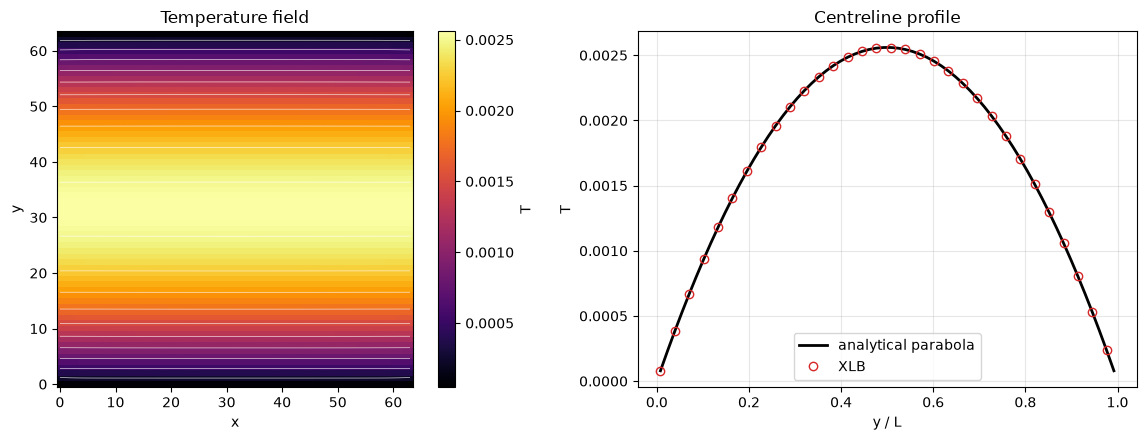

In [11]:
T = np.asarray(ZeroMoment()(g_0))[0]
profile = T[grid_shape[0] // 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im = axes[0].imshow(T.T, origin="lower", cmap="inferno")
axes[0].contour(T.T, levels=10, colors="w", linewidths=0.4)
axes[0].set_title("Temperature field")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im, ax=axes[0], label="T")

axes[1].plot(y_over_L, T_analytical, "k-", lw=2, label="analytical parabola")
axes[1].plot(y_over_L[::2], profile[::2], "o", mfc="none", mec="tab:red", label="XLB")
axes[1].set_xlabel("y / L")
axes[1].set_ylabel("T")
axes[1].set_title("Centreline profile")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "conduction_with_source.png", dpi=150)
plt.show()

The field is uniform along $x$ (as it must be, since the sides are insulated and nothing
breaks the symmetry) and parabolic in $y$, matching the analytical curve.

Notice also what the insulated sides accomplish: because no heat leaves through them, the
problem is genuinely one-dimensional and we recover the 1D slab solution on a 2D grid.

---
## Step 10 — Changing the boundary conditions

The two BC types can be recombined freely, and it is instructive to see what each one does.
Let us solve three variants on the same grid:

1. **Both walls Dirichlet, no source** — pure conduction between a hot and a cold face. The
   expected answer is a straight line, the thermal equivalent of Fourier's law in a wall.
2. **Hot wall below, insulated above, no source** — heat enters nowhere and leaves nowhere,
   so the slab must eventually reach the wall temperature everywhere.
3. **Prescribed flux below, cold above** — a constant heat flux drives a constant gradient
   $dT/dy = -\Phi/\alpha$, again a straight line but now with a slope we set directly.

In [12]:
def solve(make_bcs, num_steps=40000, source_value=0.0, phi_init=0.0, shape=grid_shape):
    """Run a thermal case to steady state and return the mid-domain profile."""
    grid = grid_factory(shape, compute_backend=compute_backend)
    bcs = make_bcs(grid.bounding_box_indices(), grid.bounding_box_indices(remove_edges=True))

    stepper = ThermalStepper(grid=grid, boundary_conditions=bcs)
    g_0, g_1, bc_mask, missing_mask = stepper.prepare_fields(phi_init=phi_init)
    u, source = stepper.prepare_aux_fields()
    if source_value != 0.0:
        source = source.at[0].set(source_value)

    for i in range(num_steps):
        g_0, g_1 = stepper(g_0, g_1, u, source, bc_mask, missing_mask, omega, i)
        g_0, g_1 = g_1, g_0

    return np.asarray(ZeroMoment()(g_0))[0][shape[0] // 2]


# 1. Hot bottom, cold top
profile_linear = solve(
    lambda box, box_no_edge: [
        ScalarDirichletBC(value=1.0, indices=box["bottom"]),
        ScalarDirichletBC(value=0.0, indices=box["top"]),
    ]
)

# 2. Hot bottom, insulated top. Only one wall can remove heat here, so this configuration
# equilibrates far more slowly than the others and needs a longer run.
profile_adiabatic = solve(
    lambda box, box_no_edge: [
        ScalarDirichletBC(value=1.0, indices=box["bottom"]),
        ScalarNeumannBC(flux=0.0, indices=box["top"]),
    ],
    num_steps=150000,
)

# 3. Prescribed flux in at the bottom, cold top
flux = 1e-4
profile_flux = solve(
    lambda box, box_no_edge: [
        ScalarNeumannBC(flux=flux, indices=box["bottom"]),
        ScalarDirichletBC(value=0.0, indices=box["top"]),
    ],
    num_steps=80000,
)

registered bc ScalarDirichletBC_300742462 with id 3
registered bc ScalarDirichletBC_301364493 with id 4
registered bc ScalarDirichletBC_301409756 with id 5
registered bc ScalarNeumannBC_301409780 with id 6
registered bc ScalarNeumannBC_301369339 with id 7
registered bc ScalarDirichletBC_301419221 with id 8


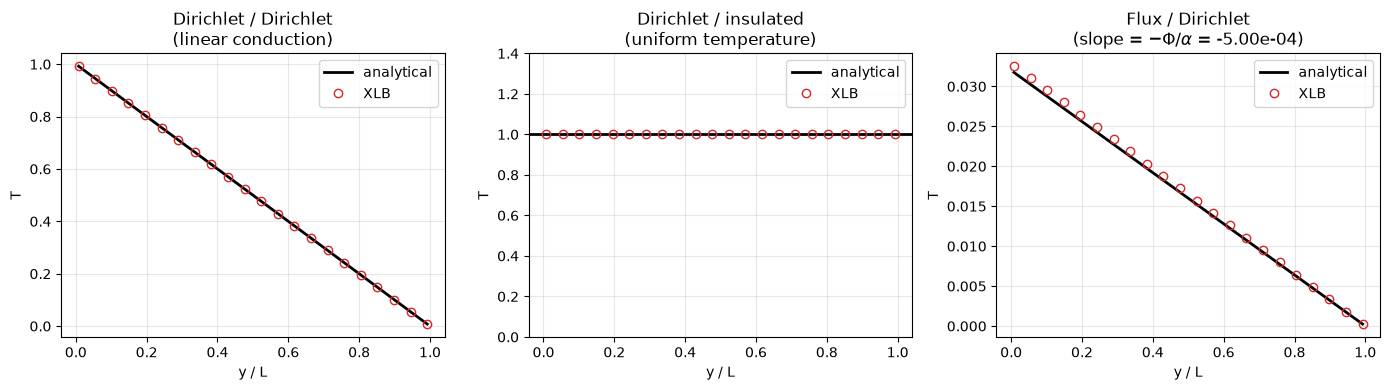

Case 1  max error vs. linear profile:  2.25e-05
Case 2  departure from uniform T = 1:  1.80e-08
Case 3  measured slope:                -5.1330e-04  (expected -5.0000e-04)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(y_over_L, 1.0 - y_over_L, "k-", lw=2, label="analytical")
axes[0].plot(y_over_L[::3], profile_linear[::3], "o", mfc="none", mec="tab:red", label="XLB")
axes[0].set_title("Dirichlet / Dirichlet\n(linear conduction)")

axes[1].axhline(1.0, color="k", lw=2, label="analytical")
axes[1].plot(y_over_L[::3], profile_adiabatic[::3], "o", mfc="none", mec="tab:red", label="XLB")
axes[1].set_ylim(0.0, 1.4)
axes[1].set_title("Dirichlet / insulated\n(uniform temperature)")

expected_flux_profile = flux / diffusivity * (ny - np.arange(ny) - 0.5)
axes[2].plot(y_over_L, expected_flux_profile, "k-", lw=2, label="analytical")
axes[2].plot(y_over_L[::3], profile_flux[::3], "o", mfc="none", mec="tab:red", label="XLB")
axes[2].set_title(f"Flux / Dirichlet\n(slope = $-\\Phi/\\alpha$ = {-flux / diffusivity:.2e})")

for ax in axes:
    ax.set_xlabel("y / L")
    ax.set_ylabel("T")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "boundary_conditions.png", dpi=150)
plt.show()

# The slope of case 3 is fitted over the interior nodes only: a one-sided difference at the
# first and last node would report the wall value rather than the gradient we are after.
interior = slice(4, -4)
measured_slope = np.polyfit(np.arange(ny)[interior], profile_flux[interior], 1)[0]

print(f"Case 1  max error vs. linear profile:  {np.abs(profile_linear - (1.0 - y_over_L)).max():.2e}")
print(f"Case 2  departure from uniform T = 1:  {np.abs(profile_adiabatic - 1.0).max():.2e}")
print(f"Case 3  measured slope:                {measured_slope:.4e}  (expected {-flux / diffusivity:.4e})")

---
## Step 11 — A transient: how heat actually spreads

Everything so far has been steady state. To close the loop, let us watch a **transient** and
check it against the other exact solution of the heat equation: the spreading of a
concentrated hot spot.

On a periodic domain with no walls and no source, an initial Gaussian of width $\sigma_0$ stays
Gaussian and simply widens,

$$\sigma^2(t) = \sigma_0^2 + 2\alpha t.$$

This is the cleanest possible test of the $\omega \leftrightarrow \alpha$ mapping, since no
boundary condition is involved at all. Note the empty `boundary_conditions=[]`: with no BCs,
streaming simply wraps around and the domain is fully periodic.

In [14]:
nx_1d = 200
grid_1d = grid_factory((nx_1d, 3), compute_backend=compute_backend)
stepper_1d = ThermalStepper(grid=grid_1d, boundary_conditions=[])

alpha_1d = 1.0 / 6.0
omega_1d = omega_from_diffusivity(alpha_1d)

x = np.arange(nx_1d)
sigma_0, x0 = 4.0, nx_1d // 2
phi_init = np.exp(-0.5 * ((x - x0) / sigma_0) ** 2)[None, :, None] * np.ones((1, nx_1d, 3))

g_0, g_1, bc_mask_1d, missing_mask_1d = stepper_1d.prepare_fields(phi_init=phi_init)
u_1d, source_1d = stepper_1d.prepare_aux_fields()

snapshots = {0: phi_init[0, :, 1].copy()}
snapshot_steps = [50, 200, 800]

for i in range(max(snapshot_steps) + 1):
    g_0, g_1 = stepper_1d(g_0, g_1, u_1d, source_1d, bc_mask_1d, missing_mask_1d, omega_1d, i)
    g_0, g_1 = g_1, g_0
    if i + 1 in snapshot_steps:
        snapshots[i + 1] = np.asarray(ZeroMoment()(g_0))[0][:, 1]

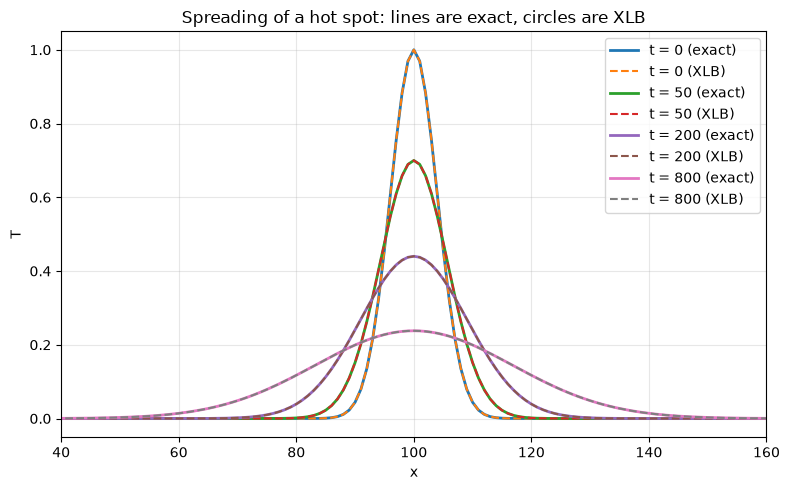

t =    0   measured sigma^2 =   16.000   expected   16.000
t =   50   measured sigma^2 =   32.667   expected   32.667
t =  200   measured sigma^2 =   82.667   expected   82.667
t =  800   measured sigma^2 =  282.667   expected  282.667


In [15]:
plt.figure(figsize=(8, 5))

for step, profile in snapshots.items():
    sigma_t = np.sqrt(sigma_0**2 + 2.0 * alpha_1d * step)
    exact = sigma_0 / sigma_t * np.exp(-0.5 * ((x - x0) / sigma_t) ** 2)

    line = plt.plot(x, exact, "-", lw=2, label=f"t = {step} (exact)")[0]
    plt.plot(x, profile, "--",
    label=f"t = {step} (XLB)")

plt.xlim(x0 - 60, x0 + 60)
plt.xlabel("x")
plt.ylabel("T")
plt.title("Spreading of a hot spot: lines are exact, circles are XLB")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "heat_kernel.png", dpi=150)
plt.show()

for step, profile in snapshots.items():
    weights = profile / profile.sum()
    centroid = np.sum(weights * x)
    variance = np.sum(weights * (x - centroid) ** 2)
    print(f"t = {step:>4d}   measured sigma^2 = {variance:8.3f}   expected {sigma_0**2 + 2.0 * alpha_1d * step:8.3f}")